<a href="https://colab.research.google.com/github/bazhenamatnenko-spec/freshlink_AI/blob/main/Freshlink_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install anthropic
import anthropic
from google.colab import userdata
import time
import json

anthropic_api_key = userdata.get('ANTHROPIC_API_KEY')
client = anthropic.Anthropic(api_key=anthropic_api_key)

print("Anthropic client initialized successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.6/753.6 kB 10.2 MB/s eta 0:00:00
Anthropic client initialized successfully.


This code gets our AI tools ready. It installs the Anthropic library, uses your secret key to connect, and sets up the AI so we can send it messages.

## Categorizing Food from Details

The overall goal of this section is to take input from the food provider (how they desribe their food) and structure it into a more organized format.

Part 1: Example Unstructured Input

In [2]:
# We simulate a real input from a business user.
business_message = (
    "We are a bakery in downtown San Jose with about 40 leftover bagels "
    "and pastries. They are packaged and need to be picked up before 7pm today."
)

This is an example message from a business about food they have. It's written in plain language, not in a format a computer can easily understand.


Part 2: Schema prompt

In [3]:
schema_prompt = """
Extract information from this food waste marketplace message.

Return ONLY valid JSON with exactly these fields:
{
  "listing_type": "OFFER" or "REQUEST",
  "actor_type": "BUSINESS" or "INDIVIDUAL" or "NONPROFIT",
  "food_category": "PRODUCE" or "BAKERY" or "PREPARED_FOOD" or "PACKAGED" or "DAIRY" or "MEAT" or "MIXED" or "COMPOST_ONLY",
  "quantity_amount": number or null,
  "quantity_unit": "LBS" or "SERVINGS" or "BOXES" or "TRAYS" or "BAGS" or "UNKNOWN",
  "pickup_location": string or null,
  "pickup_deadline": string or null,
  "storage_requirement": "ROOM_TEMP" or "REFRIGERATED" or "FROZEN" or "UNKNOWN",
  "packaging_status": "SEALED" or "PACKAGED" or "OPEN_TRAY" or "UNPACKAGED" or "UNKNOWN",
  "safety_status": "SAFE_FOR_PEOPLE" or "ANIMAL_FEED" or "COMPOST_ONLY" or "UNKNOWN",
  "urgency": "LOW" or "MEDIUM" or "HIGH"
}

Urgency guide:
LOW = pickup can happen in more than 24 hours.
MEDIUM = pickup should happen today or tomorrow.
HIGH = food must be picked up within a few hours.

No explanation. No markdown. JSON only.
"""

This section tells the AI exactly what information we need from the food messages, like food type and quantity. It's like giving the AI a form to fill out, so the information is always in a clear, organized (JSON) format.

Part 3: Extraction function

In [4]:
import base64
import io
# client is globally available from a previous cell
# Image is globally available from a previous cell

def extract_structured_food_listing(message):
    # Send the unstructured message to the AI using Anthropic's API
    # The system prompt contains our schema rules
    response = client.messages.create(
        model="claude-opus-4-6", # Changed from 'claude-3-haiku-20240307' to a working model
        max_tokens=1024,
        system=schema_prompt,
        messages=[
            {"role": "user", "content": message}
        ]
    )

    # Sleep is used to avoid rate limits (important in real apps / labs)
    # time.sleep(12)

    # Get raw text output from the model
    raw = response.content[0].text.strip()

    # Sometimes models wrap JSON in ```json ... ```
    # This removes markdown formatting if present
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()

    # Convert JSON string → Python dictionary
    # This is what your backend will actually use
    return json.loads(raw)

This code sends the plain-language food message to the AI. The AI uses our rules to pull out the key details, cleans them up, and turns them into a structured format (a Python dictionary) that our computer system can use.

Part 4: Run example

In [5]:
# Run the extraction on the sample message
result = extract_structured_food_listing(business_message)

# Print the structured output
print(json.dumps(result, indent=2, ensure_ascii=False))

{
  "listing_type": "OFFER",
  "actor_type": "BUSINESS",
  "food_category": "BAKERY",
  "quantity_amount": 40,
  "quantity_unit": "UNKNOWN",
  "pickup_location": "downtown San Jose",
  "pickup_deadline": "7pm today",
  "storage_requirement": "ROOM_TEMP",
  "packaging_status": "PACKAGED",
  "safety_status": "SAFE_FOR_PEOPLE",
  "urgency": "HIGH"
}


Here, we test our AI with the sample business message. We want to see how well it takes the free-form text and organizes it into the structured format we designed. The result is printed so we can see it clearly.

Part 5: Batch testing

In [6]:
# These simulate different types of users and food scenarios
test_messages = [
    {
        "label": "Restaurant leftovers",
        "message": "Our restaurant has 6 trays of cooked rice and vegetables left over. They are still warm and need pickup in the next hour."
    },
    {
        "label": "Grocery produce",
        "message": "We have three boxes of bruised bananas and apples. Still edible, but we cannot sell them."
    },
    {
        "label": "Resident compost",
        "message": "I have a bag of vegetable scraps from home. Not for eating, but good for compost."
    }
]

# Loop through each test case
for item in test_messages:
    print(f"=== {item['label']} ===")

    # Extract structured data for each message
    result = extract_structured_food_listing(item["message"])

    # Print results so you can debug / evaluate accuracy
    print(json.dumps(result, indent=2, ensure_ascii=False))

=== Restaurant leftovers ===
{
  "listing_type": "OFFER",
  "actor_type": "BUSINESS",
  "food_category": "PREPARED_FOOD",
  "quantity_amount": 6,
  "quantity_unit": "TRAYS",
  "pickup_location": null,
  "pickup_deadline": null,
  "storage_requirement": "ROOM_TEMP",
  "packaging_status": "OPEN_TRAY",
  "safety_status": "SAFE_FOR_PEOPLE",
  "urgency": "HIGH"
}
=== Grocery produce ===
{
  "listing_type": "OFFER",
  "actor_type": "BUSINESS",
  "food_category": "PRODUCE",
  "quantity_amount": 3,
  "quantity_unit": "BOXES",
  "pickup_location": null,
  "pickup_deadline": null,
  "storage_requirement": "ROOM_TEMP",
  "packaging_status": "UNPACKAGED",
  "safety_status": "SAFE_FOR_PEOPLE",
  "urgency": "MEDIUM"
}
=== Resident compost ===
{
  "listing_type": "OFFER",
  "actor_type": "INDIVIDUAL",
  "food_category": "COMPOST_ONLY",
  "quantity_amount": 1,
  "quantity_unit": "BAGS",
  "pickup_location": null,
  "pickup_deadline": null,
  "storage_requirement": "ROOM_TEMP",
  "packaging_status": "U

It's important to test our system with many different messages to make sure it works for everyone. This code uses various test messages (from restaurants, grocery stores, etc.) to see if the AI and our rules are strong enough to handle all kinds of real-world food descriptions.

### Food Verfication: Image Upload

In this section, the primary goal is to make classify the food into safe for consumption vs unsafe. It does this by analyzing a photo of the food. If the AI determines it is safe, it it then listed for pickup.

Part 1: Upload Food Image

Please upload an image file:


Saving Screenshot 2026-05-10 at 7.44.20 PM.png to Screenshot 2026-05-10 at 7.44.20 PM.png
Uploaded: Screenshot 2026-05-10 at 7.44.20 PM.png
Image size: 1164x964 pixels


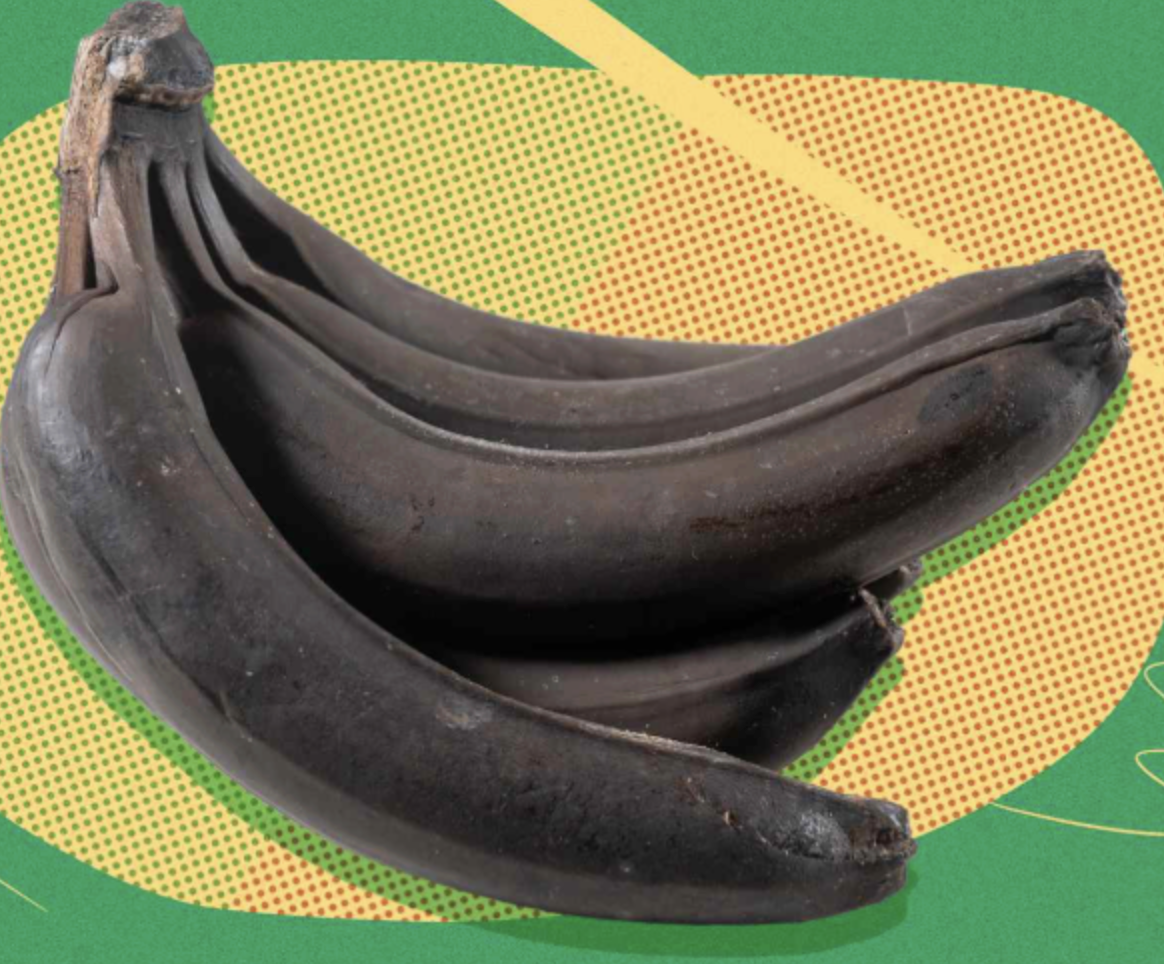

In [10]:
# Upload an image of the food.
from PIL import Image
from google.colab import files

# Upload an image file
print("Please upload an image file:")
uploaded = files.upload()

# Get the filename of the uploaded image
image_filename = list(uploaded.keys())[0]

# Open and display the uploaded image
img = Image.open(image_filename)

print(f"Uploaded: {image_filename}")
print(f"Image size: {img.size[0]}x{img.size[1]} pixels")

display(img)

This part lets you upload a picture of the food. The AI will then look at this picture to help decide what kind of food it is and if it's okay for donation. You'll see a button to upload a file after you run this cell.

Part 2: Core Food Image Analysis Function

In [22]:
import base64
import io
# client is globally available from a previous cell
# Image is globally available from a previous cell

def analyze_food_image(image_path, question):

    # Open the uploaded image.
    img = Image.open(image_path)

    # Convert PIL Image to Base64
    buffered = io.BytesIO()
    image_format = img.format if img.format else "PNG" # Default to PNG if format is unknown
    img.save(buffered, format=image_format)
    img_base64 = base64.b64encode(buffered.getvalue()).decode("utf-8")
    media_type = f"image/{image_format.lower()}"

    # Construct the messages for Anthropic API
    # Anthropic's vision models are generally claude-3 models
    model_name = "claude-opus-4-6" # Using Haiku for image analysis

    response = client.messages.create(
        model=model_name,
        max_tokens=1024, # A reasonable max_tokens for vision output
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "source": {
                            "type": "base64",
                            "media_type": media_type,
                            "data": img_base64,
                        },
                    },
                    {
                        "type": "text",
                        "text": question,
                    },
                ],
            }
        ]
    )

    # Get raw text output from the model
    response_text = response.content[0].text.strip()

    # Return the model response and token usage.
    return response_text, usage_metadata

This function sends the food picture and a question to the AI. The AI then looks at the picture to answer things like what kind of food it is, its condition, and if it's suitable for donation. It then gives us the AI's answer.

Part 3: Standard Food Marketplace Image Questions

In [16]:
import base64
import io
from PIL import Image

# client is globally available from a previous cell

# Redefine the analyze_food_image function within this cell to fix the NameError.
def analyze_food_image(image_path, question):

    # Open the uploaded image.
    img = Image.open(image_path)

    # Convert PIL Image to Base64
    buffered = io.BytesIO()
    image_format = img.format if img.format else "PNG" # Default to PNG if format is unknown
    img.save(buffered, format=image_format)
    img_base64 = base64.b64encode(buffered.getvalue()).decode("utf-8")
    media_type = f"image/{image_format.lower()}"

    # Construct the messages for Anthropic API
    model_name = "claude-opus-4-6"

    response = client.messages.create(
        model=model_name,
        max_tokens=1024,
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "source": {
                            "type": "base64",
                            "media_type": media_type,
                            "data": img_base64,
                        },
                    },
                    {
                        "type": "text",
                        "text": question,
                    },
                ],
            }
        ]
    )

    # Get raw text output from the model
    response_text = response.content[0].text.strip()

    # Return the model response and token usage.
    return response_text, response.usage # Corrected from usage_metadata

# Original content of cell 44198ef9 continues below:
# We ask the AI a set of focused questions about the food image, such as identifying the food type, its condition, and what should be done with it.
# The code loops through each question, sends it along with the image to the AI, and stores the responses.

food_questions = [
    (
        "FOOD_TYPE",
        "Identify the type of food visible in this image."
    ),
    (
        "CONDITION",
        "Describe the visible condition of the food. Does it appear fresh, packaged, opened, damaged, spoiled, or compost-only? Explain briefly."
    ),
    (
        "MARKETPLACE_ACTION",
        "Based only on what is visible, should this food be listed for human pickup, nonprofit pickup, animal feed, compost, or marked as unknown? Explain your choice."
    )
]

food_results = {
    "answers": {},
    "total_tokens": 0
}

for label, question in food_questions:
    print(f"--- {label} ---")

    # Analyze the uploaded food image using the current question.
    answer, usage = analyze_food_image(image_filename, question)

    # Save the answer under its label.
    food_results["answers"][label] = answer

    # Add token usage to the total.
    food_results["total_tokens"] += (usage.input_tokens + usage.output_tokens)

    print(answer)
    print()

print(f"--- Total tokens used: {food_results['total_tokens']} ---")

--- FOOD_TYPE ---
# Overripe Bananas

The image shows a bunch of **bananas** that are extremely overripe — their peels have turned completely **black/dark brown**. This is a natural result of the ripening process, where the sugars in the banana increase and the peel darkens due to enzymatic browning.

Despite their unappealing appearance, bananas at this stage are actually ideal for:
- **Banana bread**
- **Smoothies**
- **Banana muffins**
- **Other baked goods**

The flesh inside is typically very soft, sweet, and mushy, making it perfect for baking recipes.

--- CONDITION ---
## Condition: Spoiled / Compost-Only

The bananas are **extremely overripe and spoiled**. The peels have turned completely **black/dark brown**, indicating significant decomposition well beyond the edible overripe stage. The skin appears shriveled, dried out, and deflated in places.

While very dark bananas can sometimes still be used for baking (banana bread), these appear to have progressed **far past** even th

Here, we ask the AI several specific questions about the food picture. This helps us get details like the food type, its condition, and what should be done with it (like if it's good for people or compost). The code sends each question with the image to the AI and collects all the answers.

Part 4: Structured Listing From Image

In [17]:
structured_food_prompt = """
Analyze this food image for a food waste marketplace app.

Return ONLY valid JSON with exactly these fields:
{
  "listing_type": "OFFER" or "REQUEST" or "UNKNOWN",
  "food_category": "PRODUCE" or "BAKERY" or "PREPARED_FOOD" or "PACKAGED" or "DAIRY" or "MEAT" or "MIXED" or "COMPOST_ONLY" or "UNKNOWN",
  "estimated_quantity": string or null,
  "packaging_status": "SEALED" or "PACKAGED" or "OPEN_TRAY" or "UNPACKAGED" or "UNKNOWN",
  "visible_condition": "FRESH" or "NEAR_EXPIRY" or "DAMAGED" or "SPOILED" or "UNKNOWN",
  "storage_requirement": "ROOM_TEMP" or "REFRIGERATED" or "FROZEN" or "UNKNOWN",
  "safety_status": "LIKELY_SAFE_FOR_PEOPLE" or "COMPOST_ONLY" or "UNKNOWN",
  "recommended_action": "LIST_FOR_PICKUP" or "SEND_TO_NONPROFIT" or "COMPOST" or "NEEDS_HUMAN_REVIEW",
  "notes": string
}

Important:
Only use what is visible in the image.
Do not guess hidden details like expiration date, ingredients, or exact weight.
No markdown. No explanation outside the JSON.
"""

structured_result, structured_usage = analyze_food_image(
    image_filename,
    structured_food_prompt
)

print("--- Structured Food Listing ---")
print(structured_result)

--- Structured Food Listing ---
```json
{
  "listing_type": "OFFER",
  "food_category": "PRODUCE",
  "estimated_quantity": "1 bunch (approximately 4-5 bananas)",
  "packaging_status": "UNPACKAGED",
  "visible_condition": "SPOILED",
  "storage_requirement": "ROOM_TEMP",
  "safety_status": "COMPOST_ONLY",
  "recommended_action": "COMPOST",
  "notes": "Bananas are completely black/brown, indicating extreme overripeness or spoilage. The peels are uniformly dark with no yellow remaining. While the interior may still be usable for baking (banana bread), the external condition suggests they are past the point of fresh consumption. If the flesh inside is still intact and not fermented, they could potentially be used for baking, but based on visible exterior alone, composting is recommended."
}
```


After the AI looks at the food picture, this cell asks it to create a structured list of details, similar to how it processed text messages. This list includes things like food category, how much there is, and what to do with it, making it easy for our app to use.

Part 5: High-risk foods go to human review

In [18]:
def needs_human_review(listing):
    high_risk_categories = ["MEAT", "DAIRY", "PREPARED_FOOD"]
    risky_statuses = ["UNKNOWN", "COMPOST_ONLY"]

    # Check for known high-risk food categories
    if listing["food_category"] in high_risk_categories:
        return True

    # Check for risky safety statuses determined by AI
    if listing["safety_status"] in risky_statuses:
        return True

    # Check for packaging that might indicate higher risk or handling concerns
    if listing["packaging_status"] in ["OPEN_TRAY", "UNPACKAGED"]:
        return True

if needs_human_review(result):
    print("This listing needs human review before being published.")
else:
    print("This listing can move forward automatically.")

This listing needs human review before being published.


This function acts as a safety check. It looks at a food listing for any high-risk items (like certain meats, dairy, or unpacked food). If anything seems risky, it flags the listing for a human to review, ensuring only safe food is shared.

Part 6: Approved listings become public

In [19]:
public_listings = []

def publish_listing(listing):
    listing["status"] = "PUBLIC"
    public_listings.append(listing)
    return listing

# Example:

if not needs_human_review(result):
    published_listing = publish_listing(result)
    print("Listing published:")
    print(json.dumps(published_listing, indent=2))
else:
    result["status"] = "PENDING_REVIEW"
    print("Listing is waiting for human review.")

Listing is waiting for human review.


This code makes a food listing public on our marketplace. If the safety check passes (or a human approves it), the listing becomes available for others. If it still needs review, it won't be made public yet.

Part **7**: Users select and reserve pickup

In [20]:
# Define a simplified function for reserving a food listing.
# This function attempts to change a listing's status to 'RESERVED'.
def reserve_pickup_simplified(listing, user_name):
    # First, check if the listing's current status is 'PUBLIC'.
    # Only public listings can be reserved to prevent reserving unapproved items.
    if listing.get("status") != "PUBLIC":
        print(f"Warning: Listing is not PUBLIC. Current status: {listing.get('status')}. Cannot reserve.")
        return None # If not public, return None or raise an error.

    # If the listing is public, update its status to 'RESERVED'.
    listing["status"] = "RESERVED"
    # Record the name of the user who reserved the listing.
    listing["reserved_by"] = user_name
    return listing # Return the updated listing.

# --- Example Usage ---

# Create a sample listing that is 'PUBLIC' to demonstrate a successful reservation.
simple_listing = {
    "listing_type": "OFFER",
    "food_category": "PRODUCE",
    "status": "PUBLIC",
    "notes": "Fresh apples"
}

print("Original Simple Listing:")
print(json.dumps(simple_listing, indent=2))

# Attempt to reserve the simple_listing.
simplified_reserved_listing = reserve_pickup_simplified(simple_listing, "Bob")

# If the reservation was successful (i.e., not None), print the reserved listing.
if simplified_reserved_listing:
    print("\nSimplified Reserved Listing:")
    print(json.dumps(simplified_reserved_listing, indent=2))

# Create another sample listing that is 'PENDING_REVIEW' to demonstrate a failed reservation.
# This listing should not be reservable.
non_public_listing = {
    "listing_type": "OFFER",
    "food_category": "DAIRY",
    "status": "PENDING_REVIEW",
    "notes": "Milk for review"
}

print("\nOriginal Non-Public Listing:")
print(json.dumps(non_public_listing, indent=2))

# Attempt to reserve the non_public_listing.
reserved_non_public = reserve_pickup_simplified(non_public_listing, "Alice")
# This should print a warning and return None, so this block won't execute.
if reserved_non_public:
    print("\nReserved Non-Public Listing:")
    print(json.dumps(reserved_non_public, indent=2))


Original Simple Listing:
{
  "listing_type": "OFFER",
  "food_category": "PRODUCE",
  "status": "PUBLIC",
  "notes": "Fresh apples"
}

Simplified Reserved Listing:
{
  "listing_type": "OFFER",
  "food_category": "PRODUCE",
  "status": "RESERVED",
  "notes": "Fresh apples",
  "reserved_by": "Bob"
}

Original Non-Public Listing:
{
  "listing_type": "OFFER",
  "food_category": "DAIRY",
  "status": "PENDING_REVIEW",
  "notes": "Milk for review"
}


This function lets a user reserve food for pickup. It only works for public listings to make sure only approved food can be reserved. When a listing is reserved, its status changes, and the user's name is noted. The example shows how it works for both public and unapproved listings.